In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cv2
import glob
from analyze_videos import*
from frazil_analysis_Icefin import*
import os, sys

%load_ext autoreload
%autoreload 2
%matplotlib inline

sys.path.append(os.getcwd())
os.chdir("../../..")
savedir = os.path.join(os.getcwd(),"DATA")
path = os.getcwd()
path = os.path.join(path,"DATA/SIOS21/")

path_p = path+"MARS_ICE02_034/MARS_ICE02_034_CSV/"
# file1 = "MARS_ICE02_032_telemetry.gssbin_OPENINS_PRESSURE_STAT.csv"
file_p = "MARS_ICE02_034_1_telemetry.gssbin_OPENINS_PRESSURE_STAT.nc"
path_v = path+"MARS_ICE02_034/"
file_v_t = "video_timing_UTC.csv" # video timing
# parse the csv file of the pressure data
ds2 = xr.open_dataset(path_p + file_p, engine = "netcdf4")
ds2["depth"] = ds2.pressure_dbar * 1.0199773339984
# parse the csv file of the video timing
video_timing = pd.read_csv(path_v+file_v_t)

In [3]:
path_v

'/home/nina/pCloudDrive/DATA/SIOS21/MARS_ICE02_034/'

In [ ]:
#mp4_from_processed_frames(path_v+ "/MARS_ICE02_034_1_box_4_1635903774_65071511_frames_20.0")

generating mp4 file...


In [5]:
video_timing

,Unnamed: 0,box1 start (UTC),box1 duration (minutes),box1 file name,box2 start (UTC),box2 duration (minutes),box2 file name,box3 start (UTC),box3 duration (minutes),box3 file name,box4 start (UTC),box4 duration (minutes),box4 file name,box5 start (UTC),box5 duration (minutes),box5 file name,box6 start (UTC),box6 duration (minutes),box6 file name
0,0,2021-11-03 00:47:57.386012160,25.673333,MARS_ICE02_034_box_1_1635900477_38601208[0000]...,NaN,NaN,NaN,2021-11-03 00:47:57.385291008,32.967379,MARS_ICE02_034_box_3_1635900477_38529110[0000]...,2021-11-03 00:47:57.385673984,32.990736,MARS_ICE02_034_1_box_4_1635900477_38567400[000...,NaN,NaN,NaN,2021-11-03 00:47:57.386012160,32.996853,MARS_ICE02_034_box_6_1635900477_38601208[0000]...
1,1,2021-11-03 01:42:54.650088192,30.005000,MARS_ICE02_034_1_box_1_1635903774_65008807[000...,NaN,NaN,NaN,2021-11-03 01:42:54.650512896,29.995521,MARS_ICE02_034_1_box_3_1635903774_65051293[000...,2021-11-03 01:42:54.650715136,30.007199,MARS_ICE02_034_1_box_4_1635903774_65071511[000...,NaN,NaN,NaN,2021-11-03 01:42:54.650876928,30.005531,MARS_ICE02_034_1_box_6_1635903774_65087700[000...
2,2,2021-11-03 02:13:06.205851136,30.056111,MARS_ICE02_034_1_box_1_1635905586_20585108[000...,NaN,NaN,NaN,2021-11-03 02:13:07.207910144,30.031668,MARS_ICE02_034_1_box_3_1635905587_20791006[000...,2021-11-03 02:13:07.208928000,16.177550,MARS_ICE02_034_1_box_4_1635905587_20892811[000...,NaN,NaN,NaN,2021-11-03 02:13:07.209713920,30.039454,MARS_ICE02_034_1_box_6_1635905587_20971394[000...
3,3,2021-11-03 02:43:20.794404864,30.055556,MARS_ICE02_034_1_box_1_1635907400_79440498[000...,NaN,NaN,NaN,2021-11-03 02:43:21.796932096,30.029444,MARS_ICE02_034_1_box_3_1635907401_79693198[000...,2021-11-03 02:43:21.798311936,30.040844,MARS_ICE02_034_1_box_4_1635907401_79831195[000...,NaN,NaN,NaN,2021-11-03 02:43:21.799643904,30.039454,MARS_ICE02_034_1_box_6_1635907401_79964399[000...
4,4,2021-11-03 03:13:35.378461952,30.055000,MARS_ICE02_034_1_box_1_1635909215_37846208[000...,NaN,NaN,NaN,2021-11-03 03:13:36.380402944,30.029444,MARS_ICE02_034_1_box_3_1635909216_38040304[000...,2021-11-03 03:13:36.381253120,30.040844,MARS_ICE02_034_1_box_4_1635909216_38125300[000...,NaN,NaN,NaN,2021-11-03 03:13:36.382081024,30.038898,MARS_ICE02_034_1_box_6_1635909216_38208103[000...
5,5,2021-11-03 03:43:49.936229888,30.055000,MARS_ICE02_034_1_box_1_1635911029_93622994[000...,NaN,NaN,NaN,2021-11-03 03:43:50.938213120,30.027219,MARS_ICE02_034_1_box_3_1635911030_93821311[000...,2021-11-03 03:43:50.939068928,24.521719,MARS_ICE02_034_1_box_4_1635911030_93906903[000...,NaN,NaN,NaN,2021-11-03 03:43:50.939992832,30.038342,MARS_ICE02_034_1_box_6_1635911030_93999290[000...
6,6,2021-11-03 04:14:04.464960000,30.055000,MARS_ICE02_034_1_box_1_1635912844_46496010[000...,NaN,NaN,NaN,2021-11-03 04:14:05.466084864,30.028332,MARS_ICE02_034_1_box_3_1635912845_46608496[000...,2021-11-03 04:14:05.466883072,30.040288,MARS_ICE02_034_1_box_4_1635912845_46688294[000...,NaN,NaN,NaN,2021-11-03 04:14:05.467982080,30.037786,MARS_ICE02_034_1_box_6_1635912845_46798205[000...
7,7,2021-11-03 04:44:18.984005888,30.054444,MARS_ICE02_034_1_box_1_1635914658_98400593[000...,NaN,NaN,NaN,2021-11-03 04:44:19.986044928,30.028332,MARS_ICE02_034_1_box_3_1635914659_98604488[000...,2021-11-03 04:44:19.986932992,20.801058,MARS_ICE02_034_1_box_4_1635914659_98693299[000...,NaN,NaN,NaN,2021-11-03 04:44:19.987753984,30.037786,MARS_ICE02_034_1_box_6_1635914659_98775411[000...
8,8,2021-11-03 05:14:33.488619008,30.054444,MARS_ICE02_034_1_box_1_1635916473_48861909[000...,NaN,NaN,NaN,2021-11-03 05:14:34.490149888,30.028332,MARS_ICE02_034_1_box_3_1635916474_49014997[000...,2021-11-03 05:14:34.491052032,11.284051,MARS_ICE02_034_1_box_4_1635916474_49105191[000...,NaN,NaN,NaN,2021-11-03 05:14:34.491878912,30.038342,MARS_ICE02_034_1_box_6_1635916474_49187899[000...
9,9,2021-11-03 05:44:48.005758976,30.054444,MARS_ICE02_034_1_box_1_1635918288_00575900[000...,NaN,NaN,NaN,2021-11-03 05:44:49.007792896,30.026663,MARS_ICE02_034

bar length  2880.0  frames
[ 10.49673411 112.27352792 160.14120277 159.94451336]
frames selected at  [15.5 20.  24.5 29. ] minutes into the video
MARS_ICE02_034_1_box_4_1635903774_65071511[0000].mov
Extracing frames...
Error: Could not open video.
Extracing frames...
Error: Could not open video.
Extracing frames...
Error: Could not open video.
Extracing frames...
Error: Could not open video.
start time for ADCP comparison 2021-11-03 01:58:24.650715136


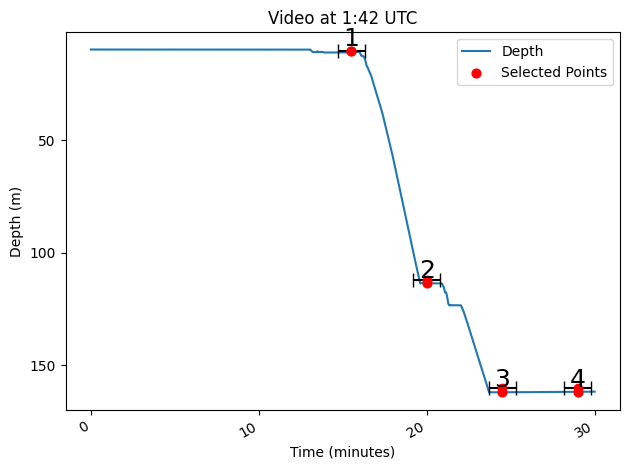

In [6]:
video_number = 1
start_time_minutes = 15.5
end_time_minutes = 29.
print("Original video: ", video_file)

time_sel1,_ = four_epochs_analysis(ds2, video_timing, video_number, start_time_minutes, end_time_minutes)
print("frames selected at ",time_sel1, "minutes into the video")
# select timing with equal spacing to match the ramps
video_file = video_timing["box4 file name"][video_number]
video_start_time1 = video_timing["box4 start (UTC)"][video_number]

for i in range(len(time_sel1)):
    start_time = time_sel1[i]
    extract_frames_period(path_v, video_file, start_time)
print("start time for ADCP comparison", pd.Timedelta(time_sel1[0], "minutes")+pd.to_datetime(video_timing["box4 start (UTC)"][video_number]))

In [7]:
for i in range(len(time_sel1)):
    start_time = time_sel1[i]
    print("Processing video file ", video_file, "at start time: ", start_time)
    output_dir1 = subtract_background(path_v, video_file, start_time)
    output_dir2 = subtract_background(path_v, video_file, start_time)
    path_processed = os.path.join(output_dir2, "with_contours")
    # mp4_from_processed_frames(path_processed, start_time)
    
    # Allocate the pressure and append
    pres = ds2.sel(
        datetime=pd.Timedelta(start_time, unit="minutes") +
        pd.to_datetime(video_timing["box4 start (UTC)"][video_number]),
        method="nearest"
    ).pressure_dbar.data

    # Allocate the video start time and append
    video_start_time = pd.Timedelta(start_time, unit="minutes") + \
                       pd.to_datetime(video_timing["box4 start (UTC)"][video_number])

Processing video file  MARS_ICE02_034_1_box_4_1635903774_65071511[0000].mov at start time:  15.5
Processing video file  MARS_ICE02_034_1_box_4_1635903774_65071511[0000].mov at start time:  20.0
Processing video file  MARS_ICE02_034_1_box_4_1635903774_65071511[0000].mov at start time:  24.5
Processing video file  MARS_ICE02_034_1_box_4_1635903774_65071511[0000].mov at start time:  29.0


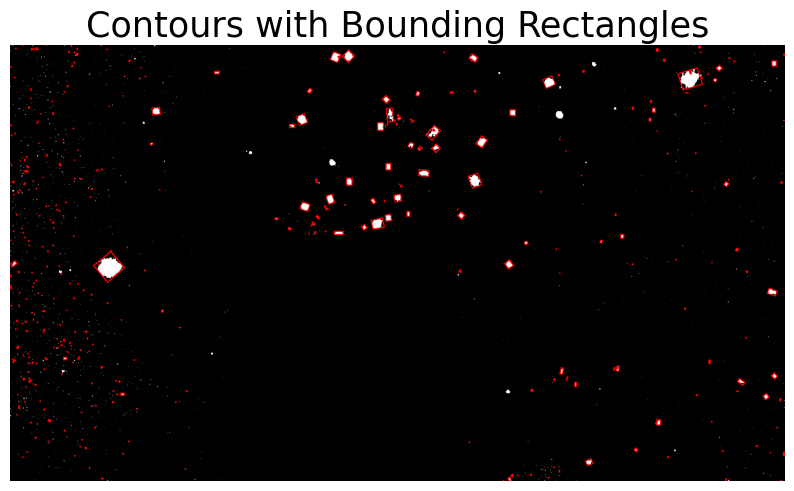

In [14]:
thresh=40
# Define the image path and load the binary image
start_time_number = 0
start_time = time_sel1[start_time_number]
image_folder = os.path.join(path_v, video_file[:-10]+ "_frames_" + str(start_time))
output_dir = os.path.join(image_folder, "background_subtracted")
processed_image_path = os.path.join(output_dir, "frame_242_foreground_clahe_masked.jpg")
processed_image = cv2.imread(processed_image_path, cv2.IMREAD_GRAYSCALE)

# Apply smallest moving average filter to reduce noise
blurred_image = cv2.blur(processed_image, (3, 3), 0)

# Threshold to create a binary image
_, binary_image = cv2.threshold(blurred_image, thresh, 255, cv2.THRESH_BINARY)

def add_rectangles(binary_image, rgb_values = (255, 0, 0)):
    # rgb values default to red
    
    # Find contours
    contours, hierarchy = cv2.findContours(binary_image, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    
    # Convert binary image to RGB for color drawing
    binary_rgb = cv2.cvtColor(binary_image, cv2.COLOR_GRAY2RGB)
    
    # Initialize list to store bounding boxes
    rectangles = []
    
    # Draw minimum bounding rectangles around each contour
    for i, contour in enumerate(contours):
        # Get the minimum area rectangle
        rect = cv2.minAreaRect(contour)
        width, height = rect[1]
        if width > 0 and height > 0:
            if (width / height) > 1 or (height / width) > 1:
                # Get the box points of the rectangle
                box = cv2.boxPoints(rect)
                box = np.intp(box)  # Convert to integer format
                # Draw the rectangle on the image
                cv2.drawContours(binary_rgb, [box], 0, rgb_values, 2)  # Red rectangles
                rectangles.append(rect)
    return binary_rgb
    
binary_rgb = add_rectangles(binary_image)
# Display the image with rectangles around the contours
plt.figure(figsize=(10, 6))
plt.imshow(binary_rgb)
plt.axis('off')
plt.title("Contours with Bounding Rectangles")
plt.show()

bar length  2880.0  frames
[69.94414446 49.72117633 29.36219762 19.41219814]
frames selected at  [ 0.9        10.26666667 19.63333333 29.        ] minutes into the video
MARS_ICE02_034_1_box_4_1635907401_79831195[0000].mov
Extracing frames...
Error: Could not open video.
Extracing frames...
Error: Could not open video.
Extracing frames...
Error: Could not open video.
Extracing frames...
Error: Could not open video.
end time for ADCP comparison 2021-11-03 03:13:09.764978603


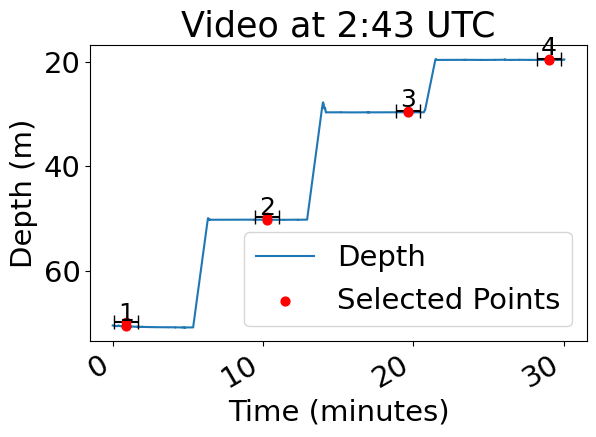

In [16]:
video_number = 3
time_sel3,_ = four_epochs_analysis(ds2, video_timing, video_number, 0.9, 29.)
print("frames selected at ",time_sel3, "minutes into the video")
# select timing with equal spacing to match the ramps
video_file = video_timing["box4 file name"][video_number]
video_start_time3 = video_timing["box4 start (UTC)"][video_number]
print(video_file)

for i in range(len(time_sel3)):
    start_time = time_sel3[i]
    extract_frames_period(path_v, video_file, start_time)
print("end time for ADCP comparison", pd.Timedelta(time_sel3[-1], "minutes")+\
      pd.Timedelta(1439/30, "seconds")+pd.to_datetime(video_timing["box4 start (UTC)"][video_number]))

In [17]:
# search for the start and end time of the first analysed video
start_time_1 = pd.to_datetime(video_timing["box4 start (UTC)"][1])
end_time_2 = pd.to_datetime(
        video_timing["box4 start (UTC)"][video_number]
    ) + pd.to_timedelta(video_timing["box4 duration (minutes)"][3], unit="m")

In [18]:
from matplotlib.gridspec import GridSpec

In [19]:
# --- Your current steps ---
# 1) Outer window
ds2w = ds2.sel(datetime=slice(start_time_1, end_time_2))

time_sel_datetime1 = pd.to_timedelta(time_sel1, unit="m") + pd.to_datetime(video_start_time1)
time_sel_datetime3 = pd.to_timedelta(time_sel3, unit="m") + pd.to_datetime(video_start_time3)

/tmp/ipykernel_58852/4188605921.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


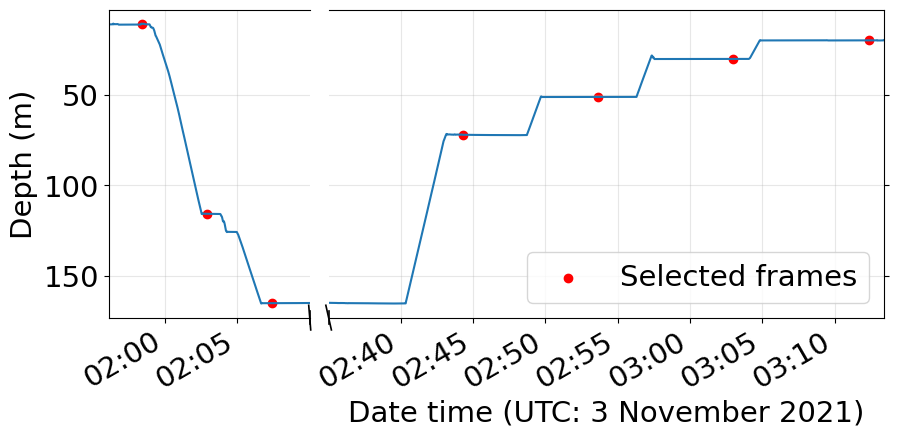

In [20]:
# 2) Middle window to remove
mid_start = pd.to_datetime("2021-11-03T02:10")
mid_end   = pd.to_datetime("2021-11-03T02:35")

# 3) Split into segments
seg1 = ds2w.sel(datetime=slice(start_time_1, mid_start))
seg2 = ds2w.sel(datetime=slice(mid_end, end_time_2))

# 4) Optional index trim on seg1
seg1 = seg1.isel(datetime=slice(20000, None))

# --- Safety checks ---
if seg1.sizes.get('datetime', 0) == 0 or seg2.sizes.get('datetime', 0) == 0:
    raise ValueError("One of the segments is empty; adjust slicing or verify time ranges.")

# --- Compute approximate width ratio (optional, for nicer balance) ---
# Use the duration of each segment to set subplot widths
dur1 = pd.Timestamp(seg1['datetime'].values[-1]) - pd.Timestamp(seg1['datetime'].values[0])
dur2 = pd.Timestamp(seg2['datetime'].values[-1]) - pd.Timestamp(seg2['datetime'].values[0])
# Guard against zero durations
dur1 = dur1 if dur1.value > 0 else pd.Timedelta('1s')
dur2 = dur2 if dur2.value > 0 else pd.Timedelta('1s')
w1, w2 = dur1.total_seconds(), dur2.total_seconds()

# --- Build the figure with two adjacent axes (broken x-axis) ---
fig = plt.figure(figsize=(10, 4))
gs = GridSpec(1, 2, width_ratios=[w1, w2], wspace=0.05)  # small wspace for tight break

ax_left = fig.add_subplot(gs[0, 0])
ax_right = fig.add_subplot(gs[0, 1], sharey=ax_left)     # share y-axis

# --- Plot segment 1 on the left axis ---
ax_left.plot(seg1['datetime'].values, seg1['depth'].values, color='C0')
ax_left.set_xlim(seg1['datetime'].values[0], seg1['datetime'].values[-1])

ax_left.scatter(time_sel_datetime1, seg1.sel(datetime=time_sel_datetime1, method="nearest")["depth"], color="red", label="Selected frames")

# --- Plot segment 2 on the right axis ---
ax_right.plot(seg2['datetime'].values, seg2['depth'].values, color='C0')
ax_right.set_xlim(seg2['datetime'].values[0], seg2['datetime'].values[-1])
ax_right.scatter(time_sel_datetime3, seg2.sel(datetime=time_sel_datetime3, method="nearest")["depth"], color="red", label="Selected frames")

# --- Styling: labels, ticks, rotation, grid ---

# Format: HH:MM (24‑hour clock)
time_formatter = mdates.DateFormatter("%H:%M")
for ax in (ax_left, ax_right):
    ax.xaxis.set_major_formatter(time_formatter)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    ax.grid(True, alpha=0.3)
ax_left.set_ylabel("Depth (m)")
# Put the x-label under the right axis (or under the figure)
ax_right.set_xlabel("Date time (UTC: 3 November 2021)")

# --- Hide the inner spines and add diagonal break marks ---
# Hide the right spine of the left axis and the left spine of the right axis
ax_left.spines['right'].set_visible(False)
ax_right.spines['left'].set_visible(False)
ax_right.yaxis.tick_right()
ax_right.tick_params(labelright=False)  # keep y tick labels only on the left

# Draw diagonal break marks (like //) between the two axes
kwargs = dict(transform=ax_left.transAxes, color='k', clip_on=False, lw=1.2)
# Left axis: draw on the right edge (x=1.0 in axes coords)
ax_left.plot([1.0, 1.0], [0.02, -0.02], **kwargs)        # small vertical tick
ax_left.plot([0.995, 1.005], [0.04, -0.04], **kwargs)    # diagonal impression

kwargs2 = dict(transform=ax_right.transAxes, color='k', clip_on=False, lw=1.2)
# Right axis: draw on the left edge (x=0.0 in axes coords)
ax_right.plot([0.0, 0.0], [0.02, -0.02], **kwargs2)
ax_right.plot([-0.005, 0.005], [0.04, -0.04], **kwargs2)

ax.invert_yaxis()

plt.legend()
plt.tight_layout()

plt.savefig("/home/nina/REPORT/Constraining_the_origin_of_frazil/figures/pressure.png", dpi=300, bbox_inches="tight")